# EDA on Vehicle Insurance Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Vehicle_Insurance.csv")

# DATA CLEANING

In [3]:
df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  str    
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  str    
 7   Vehicle_Damage        381109 non-null  str    
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), str(3)
memory usage: 34.9 MB


In [5]:
df.describe()

,id,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Response
count,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000,381109.000000
mean,190555.000000,38.822584,0.997869,26.388807,0.458210,30564.389581,112.034295,154.347397,0.122563
std,110016.836208,15.511611,0.046110,13.229888,0.498251,17213.155057,54.203995,83.671304,0.327936
min,1.000000,20.000000,0.000000,0.000000,0.000000,2630.000000,1.000000,10.000000,0.000000
25%,95278.000000,25.000000,1.000000,15.000000,0.000000,24405.000000,29.000000,82.000000,0.000000
50%,190555.000000,36.000000,1.000000,28.000000,0.000000,31669.000000,133.000000,154.000000,0.000000
75%,285832.000000,49.000000,1.000000,35.000000,1.000000,39400.000000,152.000000,227.000000,0.000000
max,381109.000000,85.000000,1.000000,52.000000,1.000000,540165.000000,163.000000,299.000000,1.000000


In [6]:
df.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

--> No null values were found.

In [7]:
df.drop_duplicates(inplace=True)

# Handling outliers

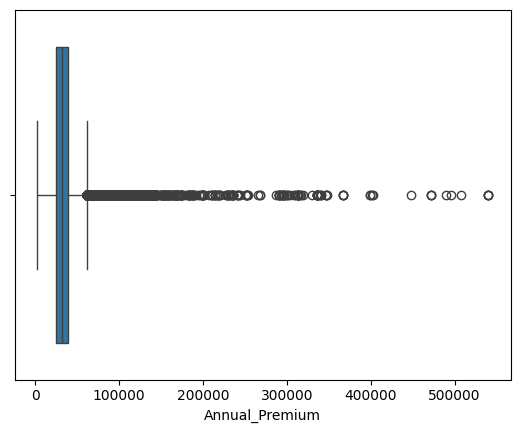

In [8]:
sns.boxplot(x=df['Annual_Premium'])
plt.show()

--> As we can see our data is highly right-skewed

--> And contains extreme high-value outliers

In [9]:
Q1 = df['Annual_Premium'].quantile(0.25)
Q3 = df['Annual_Premium'].quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [10]:
df_clean = df[(df['Annual_Premium'] >= lower_bound) & (df['Annual_Premium'] <= upper_bound)]

In [11]:
df_clean.head(2)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0


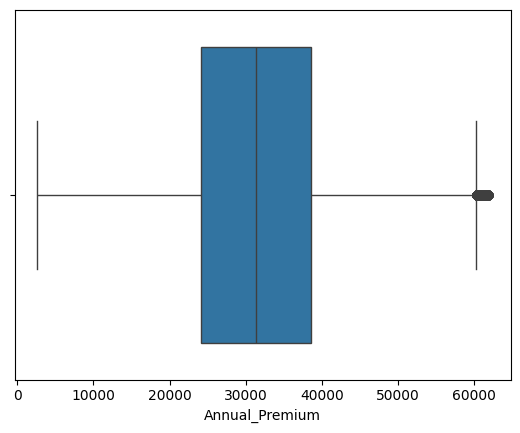

In [12]:
sns.boxplot(x=df_clean['Annual_Premium'])
plt.show()

# Visualization

# Age Distribution

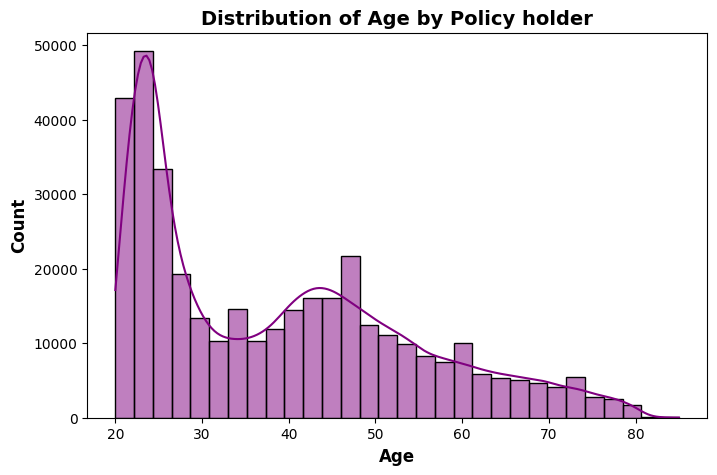

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(data=df_clean, x='Age', bins=30, kde=True, color='purple')

plt.title("Distribution of Age by Policy holder",fontsize=14, fontweight='bold')
plt.xlabel("Age",fontsize=12, fontweight='bold')
plt.ylabel("Count",fontsize=12, fontweight='bold')

plt.show()

# Gender and Response

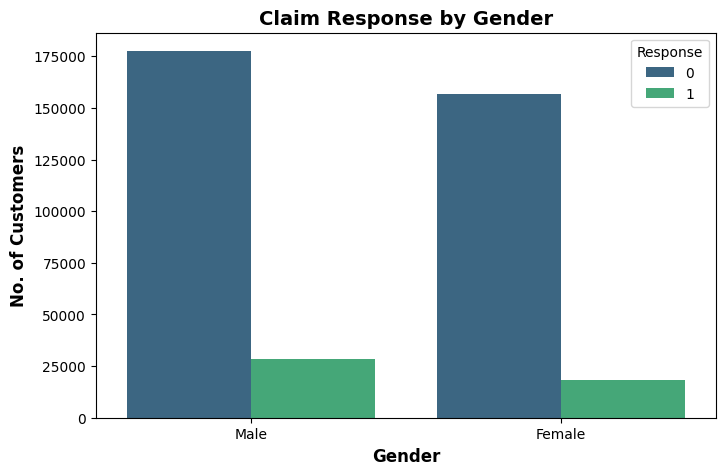

In [19]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Gender', hue='Response', data=df, palette='viridis')
plt.title('Claim Response by Gender',fontsize=14, fontweight='bold')
plt.xlabel("Gender",fontsize=12, fontweight='bold')
plt.ylabel("No. of Customers",fontsize=12, fontweight='bold')
plt.show()

# Vehicle Age VS Response

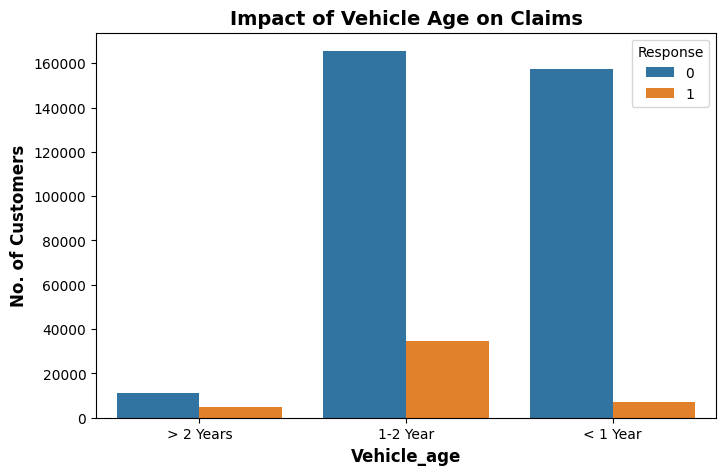

In [26]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Vehicle_Age', hue='Response', data=df)
plt.title('Impact of Vehicle Age on Claims',fontsize=14, fontweight='bold')
plt.xlabel("Vehicle_age",fontsize=12, fontweight='bold')
plt.ylabel("No. of Customers",fontsize=12, fontweight='bold')
plt.show()

# Annual Premium Vs Claim Response

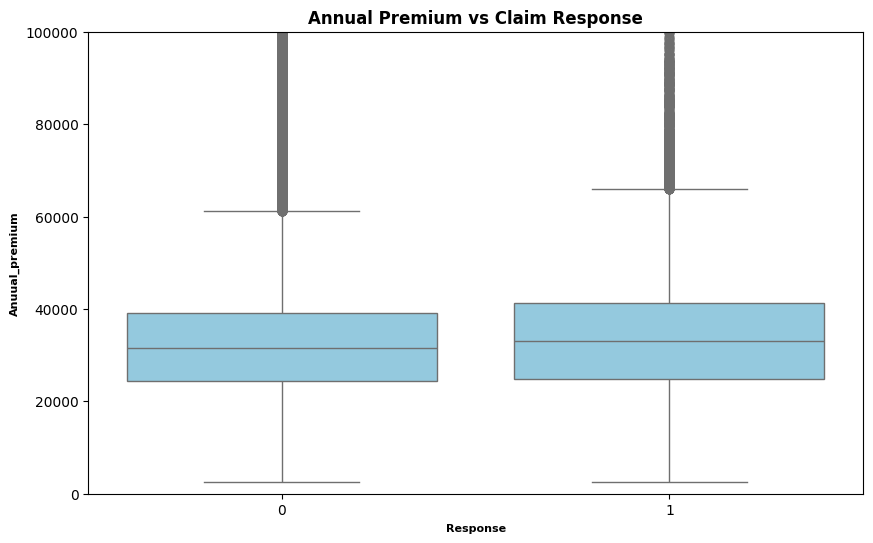

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Response', y='Annual_Premium', data=df, color="skyblue")
plt.title('Annual Premium vs Claim Response',fontsize=12, fontweight="bold")
plt.xlabel("Response",fontsize=8, fontweight='bold')
plt.ylabel("Anuual_premium",fontsize=8, fontweight='bold')
plt.ylim(0, 100000)
plt.show()

# Correlation heatmap

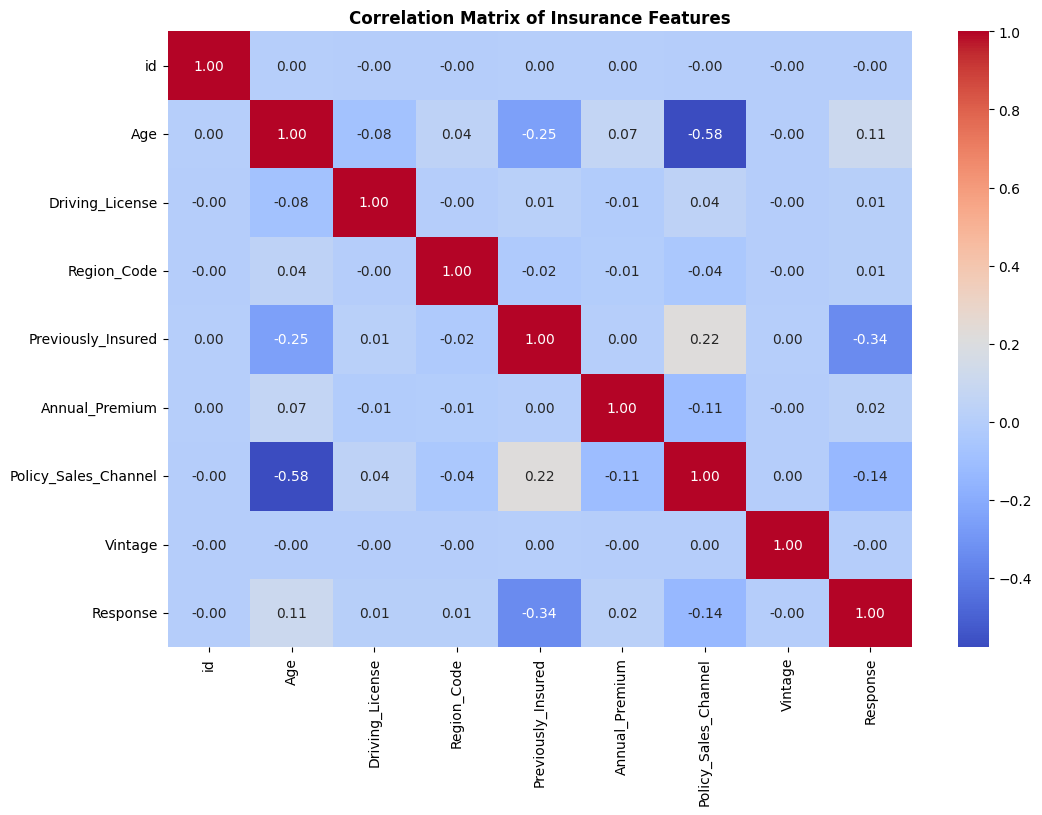

In [33]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Insurance Features', fontweight="bold")
plt.show()

# Project conclusion:

* **Vehicle Age is a Huge Factor:** People with cars older than a year are much more likely to buy insurance than those with brand-new cars. It seems the risk of maintenance or accidents on older vehicles drives them to seek coverage.
* **The "Uninsured" Goldmine:** We found that customers who are already insured almost never switch. The best return on investment for the company is to target those who currently have no insurance at all.
* **Middle-Aged Sweet Spot:** Interest peaks among drivers in their 30s and 40s. While young drivers are high-risk, the middle-aged demographic shows the most actual intent to purchase.
* **Channel Efficiency:** Not all sales channels are equal. High-volume channels (like automated emails) have more reach but very low conversion, whereas direct or agent-based channels bring in the most committed customers.
* **Price isn't the Only Barrier:** Interestingly, higher premiums don't always scare off customers. Those who feel they are at high risk (due to past damage or old cars) are willing to pay more for the security.